# Soil Erosion Baseline LEAF Generation
Baseline soil erosion LEAF were developed for the same land use maps than SOC LEAFs. In this case, despite LEAF existing for both irrigated and rainfed land uses, there is no difference. LEAFs have been generated differentiating crop residue management practices, as well as **TODO: conventional and reduced tillage**.

As mentioned in the [Soil Erosion Documentation](../documentation/Soil_Erosion_Documentation.md), soil erosion LEAFs are generated using the RUSLE equation, which needs both soil and weather data ($R$, $K_{st}$, and $LS$), and crop and land management relaed ($C$ and $P$).

## Step 1 - RLSK Layer
A single layer is used to speed up the process, and has been generated as the simply multiplication of R$, $K_{st}$, and $LS$ rasters. 

Then, importing and familiarizing with the needed files...

In [1]:
# Modules
import sbtn_leaf.map_plotting as mp
import sbtn_leaf.map_calculations as mc
import polars as pl
import numpy as np
import os
import geopandas as gpd
import matplotlib.pyplot as plt
import rasterio

Could not determine dtype for column 1, falling back to string


In [2]:
# Filepaths
k_fp = "../data/soil_erosion/GloSEM_v1.1/RUSLE_KFactor_v1.1_25km.tif"
ls_fp = "../data/soil_erosion/GloSEM_v1.1/RUSLE_LSFactor_v1.1_25km.tif"
r_fp = "../data/soil_erosion/GloSEM_v1.1/RUSLE_RFactor_v1.1_25km.tif"

In [4]:
mp.inspect_raster(k_fp)

File: ../data/soil_erosion/GloSEM_v1.1/RUSLE_KFactor_v1.1_25km.tif
Driver: GTiff
Width, Height: 1728, 673
Number of Bands: 1
CRS: EPSG:4326
Bounds: BoundingBox(left=-180.0, bottom=-56.6229166666667, right=179.99999999999943, top=83.58541666666642)
Pixel Size: (0.208333333333333, 0.208333333333333)
No-data Value: -3.4028234663852886e+38

--- Raster Metadata ---
TIFFTAG_SOFTWARE: GDAL 3.8.1e (3080114) (4.6.0;1710;3.0.1;2.1.6;;0x10302;5.4.5;), PROJ 9.3.1 (EPSG.VERSION=v10.098;EPSG.DATE=2023-11-24;ESRI.VERSION=ArcGIS Pro 3.2;ESRI.DATE=2023-11-02;PROJ_DATA.VERSION=1.16;)
AREA_OR_POINT: Area

--- Band Information ---

Band 1:
  Data Type: float32
  Min Value: 0.0046822563745081425
  Max Value: 0.05668995901942253
  Mean Value: 0.026686985045671463
  Standard Deviation: 0.007201943080872297
  Band Metadata:
    STATISTICS_MAXIMUM: 0.056689959019423
    STATISTICS_MEAN: 0.026686986377999
    STATISTICS_MINIMUM: 0.0046822563745081
    STATISTICS_SKIPFACTORX: 1
    STATISTICS_SKIPFACTORY: 1
    

Raster has 24,328 unique values. Min: 0.00. Max: 0.06
Using quantiles
All positives route (quantiles)


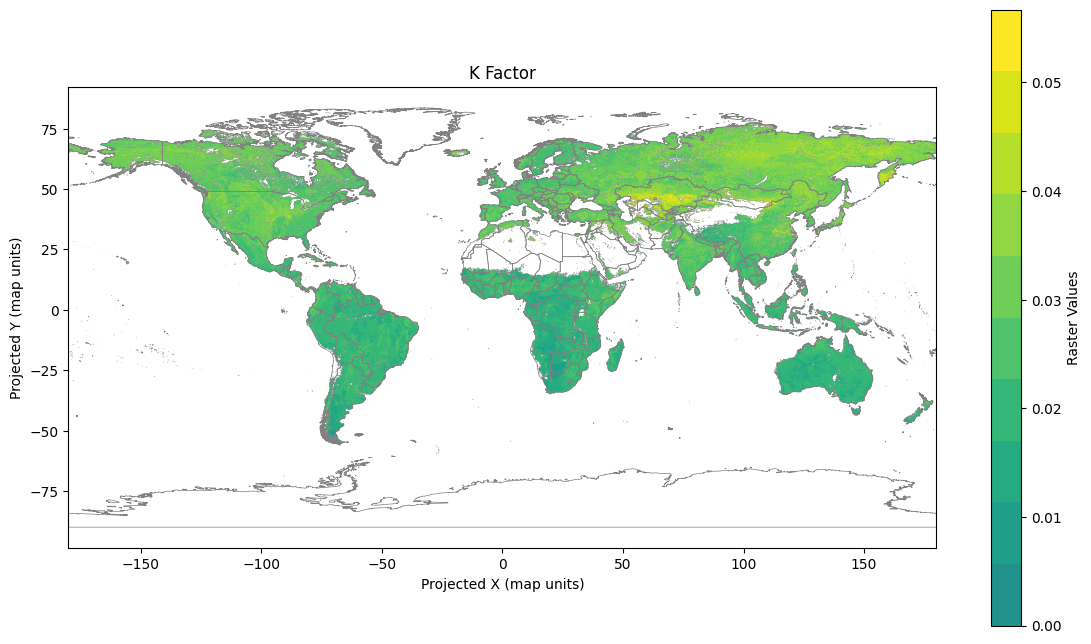

In [6]:
mp.plot_raster_on_world_extremes_cutoff(k_fp, "K Factor", perc_cutoff=0, quantiles=10)

Raster has 220,799 unique values. Min: 0.15. Max: 38.19
Using quantiles
All positives route (quantiles)


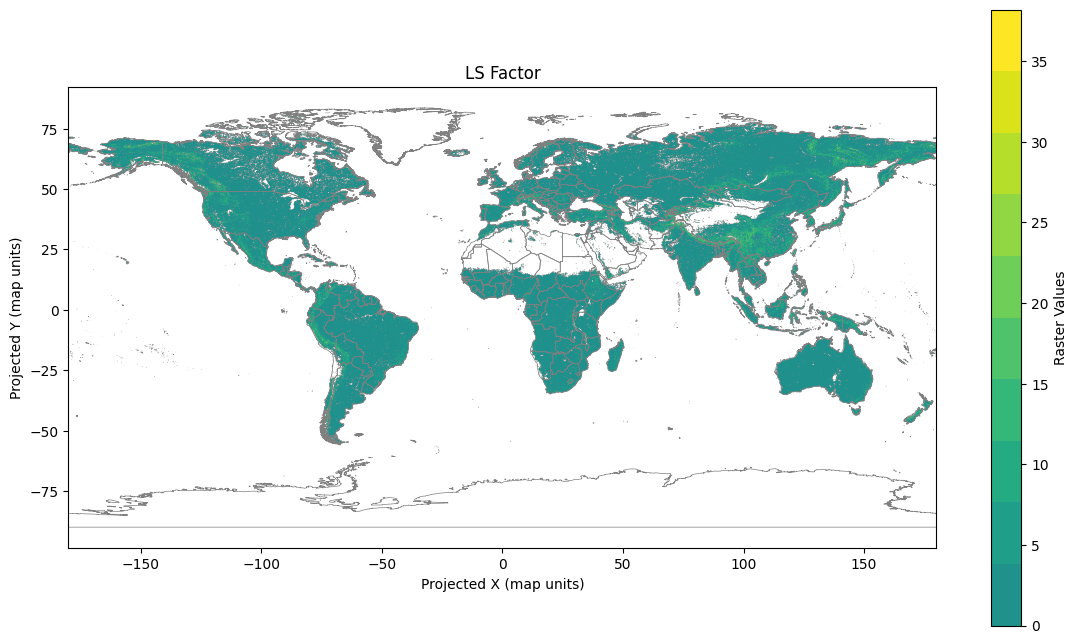

In [7]:
mp.plot_raster_on_world_extremes_cutoff(ls_fp, "LS Factor", perc_cutoff=0, quantiles=10)

C:\Users\loyola\OneDrive - World Wildlife Fund, Inc\Documents\203. Python projects\SBTN_Test\src\sbtn_leaf\map_plotting.py:219: RuntimeWarning: overflow encountered in cast
  data = src.read(raster_band).astype("float32", copy=False)
C:\Users\loyola\OneDrive - World Wildlife Fund, Inc\Documents\203. Python projects\SBTN_Test\src\sbtn_leaf\map_plotting.py:91: RuntimeWarning: overflow encountered in cast
  out[out == nodata_value] = np.nan


Raster has 277,777 unique values. Min: 0.00. Max: 26,179.59
Using quantiles
All positives route (quantiles)


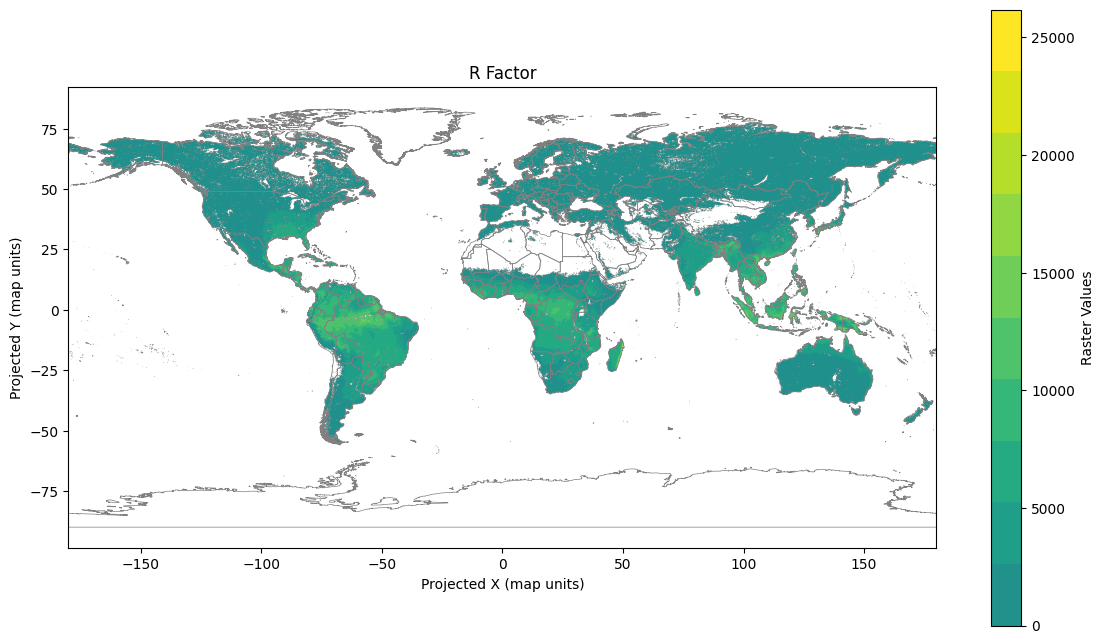

In [8]:
mp.plot_raster_on_world_extremes_cutoff(r_fp, "R Factor", perc_cutoff=0, quantiles=10)

In [9]:
mp.inspect_raster(ls_fp)

File: ../data/soil_erosion/GloSEM_v1.1/RUSLE_LSFactor_v1.1_25km.tif
Driver: GTiff
Width, Height: 1728, 673
Number of Bands: 1
CRS: EPSG:4326
Bounds: BoundingBox(left=-180.0, bottom=-56.6229166666667, right=179.99999999999943, top=83.58541666666642)
Pixel Size: (0.208333333333333, 0.208333333333333)
No-data Value: -3.4028234663852886e+38

--- Raster Metadata ---
TIFFTAG_SOFTWARE: GDAL 3.8.1e (3080114) (4.6.0;1710;3.0.1;2.1.6;;0x10302;5.4.5;), PROJ 9.3.1 (EPSG.VERSION=v10.098;EPSG.DATE=2023-11-24;ESRI.VERSION=ArcGIS Pro 3.2;ESRI.DATE=2023-11-02;PROJ_DATA.VERSION=1.16;)
AREA_OR_POINT: Area

--- Band Information ---

Band 1:
  Data Type: float32
  Min Value: 0.15429238975048065
  Max Value: 38.18529510498047
  Mean Value: 1.7793327569961548
  Standard Deviation: 3.262052059173584
  Band Metadata:
    STATISTICS_MAXIMUM: 38.18529510498
    STATISTICS_MEAN: 1.7793328181477
    STATISTICS_MINIMUM: 0.15429238975048
    STATISTICS_SKIPFACTORX: 1
    STATISTICS_SKIPFACTORY: 1
    STATISTICS_STDD

As expected from sourcing all layers from a single reference, they all coincide in their GIS properties and can be multiplied without further transformations.

In [13]:
# Defining raster list
rlsk_inputs = [r_fp, ls_fp, k_fp]
rlsk_fp = "../data/soil_erosion/rlsk_2012.tif"

rlsk = mc.multiply_rasters(rlsk_inputs, output_path=rlsk_fp)

Raster saved into ../data/soil_erosion/rlsk_2012.tif


Inspecting the results...

In [11]:
mp.inspect_raster(rlsk_fp)

File: ../data/soil_erosion/rlsk_2012.tif
Driver: GTiff
Width, Height: 1728, 673
Number of Bands: 1
CRS: EPSG:4326
Bounds: BoundingBox(left=-180.0, bottom=-56.6229166666667, right=179.99999999999943, top=83.58541666666642)
Pixel Size: (0.208333333333333, 0.208333333333333)
No-data Value: -1.7976931348623157e+308

--- Raster Metadata ---
AREA_OR_POINT: Area

--- Band Information ---

Band 1:
  Data Type: float64
  Min Value: 0.0
  Max Value: 10179.745188638457
  Mean Value: 96.62198062560604
  Standard Deviation: 294.14528533731226


C:\Users\loyola\OneDrive - World Wildlife Fund, Inc\Documents\203. Python projects\SBTN_Test\src\sbtn_leaf\map_plotting.py:219: RuntimeWarning: overflow encountered in cast
  data = src.read(raster_band).astype("float32", copy=False)
C:\Users\loyola\OneDrive - World Wildlife Fund, Inc\Documents\203. Python projects\SBTN_Test\src\sbtn_leaf\map_plotting.py:91: RuntimeWarning: overflow encountered in cast
  out[out == nodata_value] = np.nan


Raster has 278,031 unique values. Min: 0.00. Max: 10,179.75
Using quantiles
All positives route (quantiles)


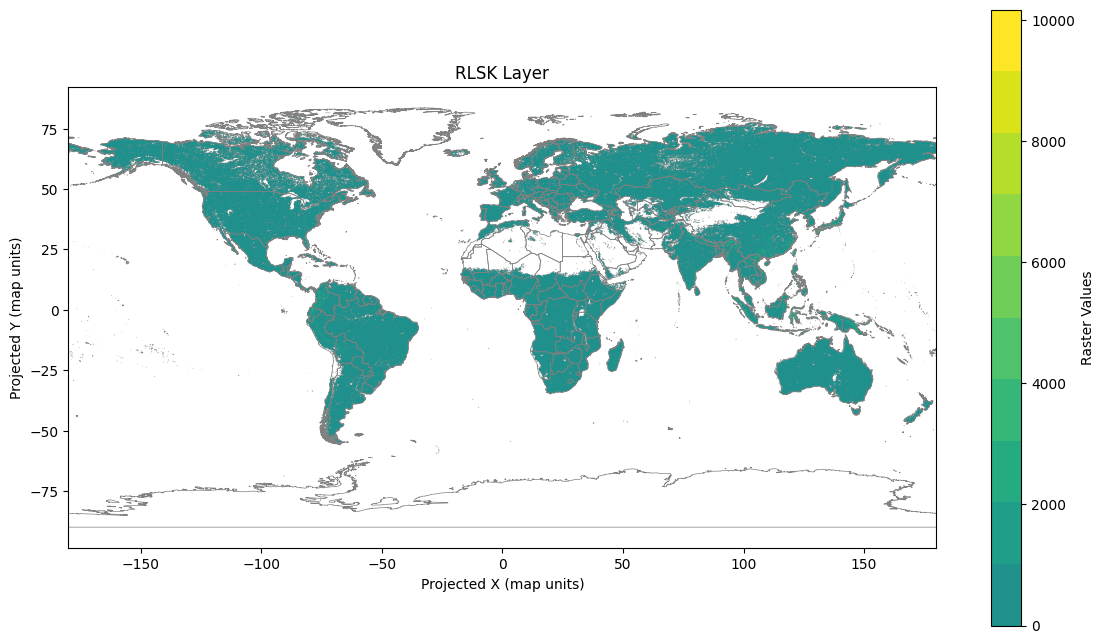

In [16]:
mp.plot_raster_on_world_extremes_cutoff("../data/soil_erosion/rlsk_2012.tif", title="RLSK Layer", perc_cutoff=0, quantiles=10)

Which shows that the layer has been correctly generated. Moving on.

## Step 2 - Crop C-Factor
Next step is generating a layer of C factors for each land use map. In this case, C-factors are assigned according to tables 1 and 2 of Soil Erosion Documentation, which have been pre-assigned and can be found on the file [`lu_c_factor_inventory`](../data/crops/lu_c_factor_inventory.xlsx). This file additionally contains all raster names, paths, commodities and their categorization, irrigation type, and crop residues management type.

Importing the file and inspecting the file

In [5]:
files_inventory = pl.read_excel("../data/crops/lu_c_factor_inventory.xlsx")

In [9]:
files_inventory.head(15)

file_name,land_use,path,crop_name,irrigation_type,on_off_field,commodity_type,crop_type,crop_class,crop_subclass,c_crop,c_res,c_final
str,str,str,str,str,str,str,str,str,str,f64,f64,f64
"""lu_Broadleaf_Deciduous_Boreal_…","""Broadleaf_Deciduous_Boreal_dry""","""../data/land_use/lu_Broadleaf_…","""Broadleaf_Deciduous_Boreal_dry""","""NA""","""NA""","""Forest""",null,"""Forest""","""Natural""",0.003,1.0,0.003
"""lu_Broadleaf_Deciduous_Boreal_…","""Broadleaf_Deciduous_Boreal_moi…","""../data/land_use/lu_Broadleaf_…","""Broadleaf_Deciduous_Boreal_moi…","""NA""","""NA""","""Forest""",null,"""Forest""","""Natural""",0.003,1.0,0.003
"""lu_Broadleaf_Deciduous_Cold_te…","""Broadleaf_Deciduous_Cold_tempe…","""../data/land_use/lu_Broadleaf_…","""Broadleaf_Deciduous_Cold_tempe…","""NA""","""NA""","""Forest""",null,"""Forest""","""Natural""",0.003,1.0,0.003
"""lu_Broadleaf_Deciduous_Cold_te…","""Broadleaf_Deciduous_Cold_tempe…","""../data/land_use/lu_Broadleaf_…","""Broadleaf_Deciduous_Cold_tempe…","""NA""","""NA""","""Forest""",null,"""Forest""","""Natural""",0.003,1.0,0.003
"""lu_Broadleaf_Deciduous_Subtrop…","""Broadleaf_Deciduous_Subtropica…","""../data/land_use/lu_Broadleaf_…","""Broadleaf_Deciduous_Subtropica…","""NA""","""NA""","""Forest""",null,"""Forest""","""Natural""",0.003,1.0,0.003
…,…,…,…,…,…,…,…,…,…,…,…,…
"""lu_Irrigated_Bananas.tif""","""Irrigated_Bananas""","""C:\Users\loyola\OneDrive - Wor…","""Bananas""","""Irrigated""","""NA""","""permanent_crop""","""permanent""","""Fruit_Trees""","""Various""",0.15,1.0,0.15
"""lu_Irrigated_Barley_residues_l…","""Irrigated_Barley_residues_left…","""C:\Users\loyola\OneDrive - Wor…","""Barley""","""Irrigated""","""on""","""annual_crop""","""annual""","""Cereals""","""Various""",0.2,0.88,0.176
"""lu_Irrigated_Barley_residues_r…","""Irrigated_Barley_residues_remo…","""C:\Users\loyola\OneDrive - Wor…","""Barley""","""Irrigated""","""off""","""annual_crop""","""annual""","""Cereals""","""Various""",0.2,1.0,0.2


Next step is to generate the C-Factor value in the original land use raster resolution (~10km) and then downsampling to 25km from the RLSK layer. The 10km files have not been preserved, but can be generated as follow:

In [10]:
output_folder = "../data/soil_erosion/C_Factors/10km/"

In [11]:
for row in files_inventory.iter_rows(named=True):
    input_path = row["path"]
    c_factor = row["c_final"]
    land_use_type = row["land_use"]
    output_path = output_folder + "cfactor_10km_" + land_use_type + ".tif"

    print(f"Rasterizing {land_use_type} land use with a c factor of {c_factor}")

    mc.create_binary_mask(input_path, output_path, binary_value=c_factor, src_nodata=255, dst_nodata=np.nan)
    print(f"{land_use_type} rasterized succesfully!\n")

Rasterizing Broadleaf_Deciduous_Boreal_dry land use with a c factor of 0.003
Input No Data defined as 255. Value 0.003 if is not 255 and nan if it is.
Broadleaf_Deciduous_Boreal_dry rasterized succesfully!

Rasterizing Broadleaf_Deciduous_Boreal_moist land use with a c factor of 0.003
Input No Data defined as 255. Value 0.003 if is not 255 and nan if it is.
Broadleaf_Deciduous_Boreal_moist rasterized succesfully!

Rasterizing Broadleaf_Deciduous_Cold_temperate_dry land use with a c factor of 0.003
Input No Data defined as 255. Value 0.003 if is not 255 and nan if it is.
Broadleaf_Deciduous_Cold_temperate_dry rasterized succesfully!

Rasterizing Broadleaf_Deciduous_Cold_temperate_moist land use with a c factor of 0.003
Input No Data defined as 255. Value 0.003 if is not 255 and nan if it is.
Broadleaf_Deciduous_Cold_temperate_moist rasterized succesfully!

Rasterizing Broadleaf_Deciduous_Subtropical land use with a c factor of 0.003
Input No Data defined as 255. Value 0.003 if is not 25

And the downsampling can be perform then as:

In [14]:
input_folder = "../data/soil_erosion/C_Factors/10km/"
output_folder = "../data/soil_erosion/C_Factors/25km/"

for file in os.listdir(input_folder):
    # file names
    file_name = os.path.basename(file)
    new_file_name = file_name.replace("10km", "25km")
    input_path = input_folder + file_name
    output_path = output_folder + new_file_name
    
    # Operation
    mc.resample_to_match(src_path=input_path, target_path=rlsk_fp, output_path=output_path)
    print(f"{file_name} resampled into rlsk raster resolution")
    

cfactor_10km_Barley_irr_roff_rt.tif resampled into rlsk raster resolution
cfactor_10km_Barley_irr_ron_rt.tif resampled into rlsk raster resolution
cfactor_10km_Barley_rf_roff_rt.tif resampled into rlsk raster resolution
cfactor_10km_Barley_rf_ron_rt.tif resampled into rlsk raster resolution
cfactor_10km_Broadleaf_Deciduous_Boreal_dry.tif resampled into rlsk raster resolution
cfactor_10km_Broadleaf_Deciduous_Boreal_moist.tif resampled into rlsk raster resolution
cfactor_10km_Broadleaf_Deciduous_Cold_temperate_dry.tif resampled into rlsk raster resolution
cfactor_10km_Broadleaf_Deciduous_Cold_temperate_moist.tif resampled into rlsk raster resolution
cfactor_10km_Broadleaf_Deciduous_Subtropical.tif resampled into rlsk raster resolution
cfactor_10km_Broadleaf_Deciduous_Tropical.tif resampled into rlsk raster resolution
cfactor_10km_Broadleaf_Deciduous_Warm_temperate_dry.tif resampled into rlsk raster resolution
cfactor_10km_Broadleaf_Deciduous_Warm_temperate_moist.tif resampled into rlsk r

Inpsecting wheat as it has both crop residues management options

In [15]:
mp.inspect_raster("../data/soil_erosion/C_Factors/25km/cfactor_25km_Rainfed_Wheat_residues_removed_from_the_field.tif")

File: ../data/soil_erosion/C_Factors/25km/cfactor_25km_Rainfed_Wheat_residues_removed_from_the_field.tif
Driver: GTiff
Width, Height: 1728, 673
Number of Bands: 1
CRS: EPSG:4326
Bounds: BoundingBox(left=-180.0, bottom=-56.6229166666667, right=179.99999999999943, top=83.58541666666642)
Pixel Size: (0.208333333333333, 0.208333333333333)
No-data Value: nan

--- Raster Metadata ---
AREA_OR_POINT: Area

--- Band Information ---

Band 1:
  Data Type: float32
  Min Value: 0.20000000298023224
  Max Value: 0.20000000298023224
  Mean Value: 0.20000001788139343
  Standard Deviation: 1.4901161193847656e-08


Raster has 1 unique values. Min: 0.20. Max: 0.20


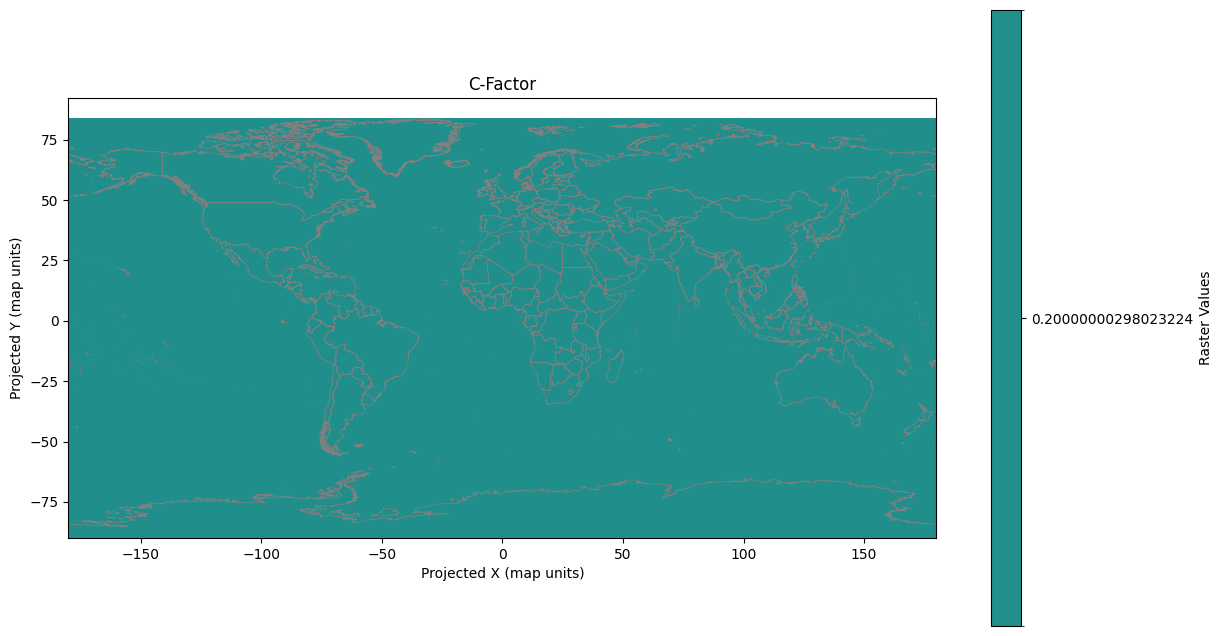

In [17]:
mp.plot_raster_on_world_extremes_cutoff("../data/soil_erosion/C_Factors/10km/cfactor_10km_Rainfed_Wheat_residues_removed_from_the_field.tif", "C-Factor", perc_cutoff=0, eliminate_zeros=True)

In [18]:
mp.inspect_raster("../data/soil_erosion/C_Factors/25km/cfactor_25km_Rainfed_Wheat_residues_left_on_the_field.tif")

File: ../data/soil_erosion/C_Factors/25km/cfactor_25km_Rainfed_Wheat_residues_left_on_the_field.tif
Driver: GTiff
Width, Height: 1728, 673
Number of Bands: 1
CRS: EPSG:4326
Bounds: BoundingBox(left=-180.0, bottom=-56.6229166666667, right=179.99999999999943, top=83.58541666666642)
Pixel Size: (0.208333333333333, 0.208333333333333)
No-data Value: nan

--- Raster Metadata ---
AREA_OR_POINT: Area

--- Band Information ---

Band 1:
  Data Type: float32
  Min Value: 0.17599999904632568
  Max Value: 0.17599999904632568
  Mean Value: 0.17599999904632568
  Standard Deviation: 0.0


Raster has 1 unique values. Min: 0.18. Max: 0.18


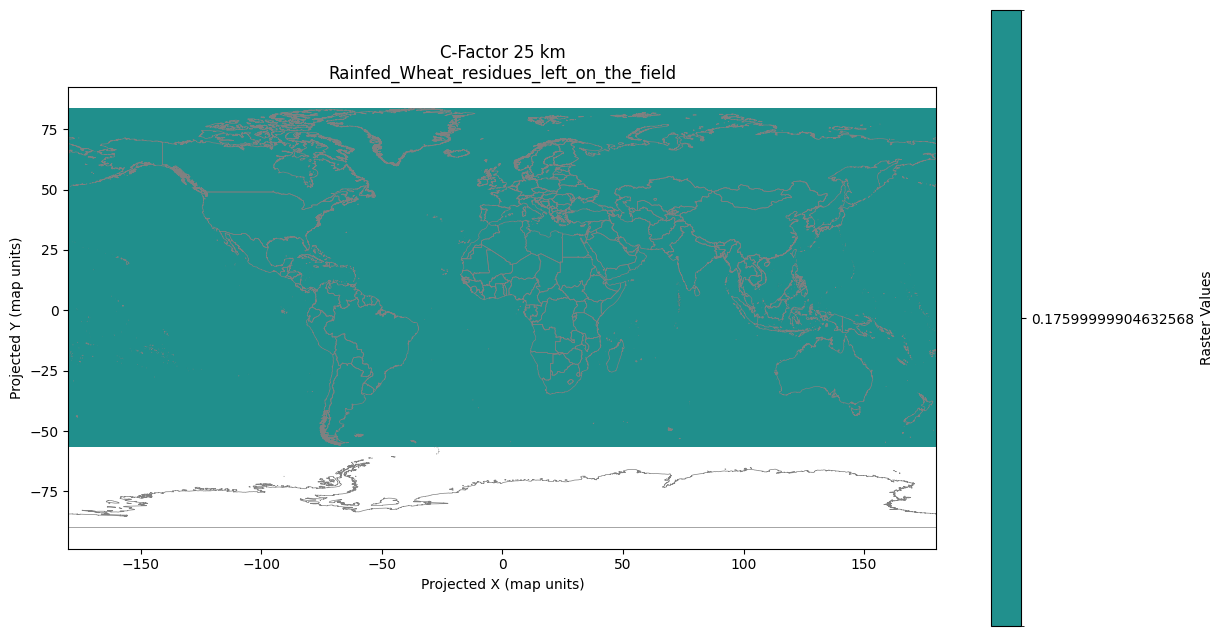

In [19]:
mp.plot_raster_on_world_extremes_cutoff("../data/soil_erosion/C_Factors/25km/cfactor_25km_Rainfed_Wheat_residues_left_on_the_field.tif", "C-Factor 25 km\nRainfed_Wheat_residues_left_on_the_field", perc_cutoff=0)

## Step 3 - Calculate LEAFs Soil Erosion for each land use
Now that both the RLSK layer and the C-Factor layers have been generated, soil erosion factors can be simply calculated as the multiplication of both. 

This can be done as:

In [20]:
input_folder = "../data/soil_erosion/C_Factors/25km/"
output_folder = "../LEAFs/soil_erosion/"

for file in os.listdir(input_folder):
    # file names
    file_name = os.path.basename(file)
    new_file_name = file_name.replace("cfactor", "se_rate")
    input_path = input_folder + file_name
    output_path = output_folder + new_file_name
    
    # Operation
    mc.multiply_rasters([rlsk_fp, input_path], output_path)
    print(f"Soil erosion calculated for {file_name}")

Raster saved into ../LEAFs/soil_erosion/se_rate_25km_Barley_irr_roff_rt.tif
Soil erosion calculated for cfactor_25km_Barley_irr_roff_rt.tif
Raster saved into ../LEAFs/soil_erosion/se_rate_25km_Barley_irr_ron_rt.tif
Soil erosion calculated for cfactor_25km_Barley_irr_ron_rt.tif
Raster saved into ../LEAFs/soil_erosion/se_rate_25km_Barley_rf_roff_rt.tif
Soil erosion calculated for cfactor_25km_Barley_rf_roff_rt.tif
Raster saved into ../LEAFs/soil_erosion/se_rate_25km_Barley_rf_ron_rt.tif
Soil erosion calculated for cfactor_25km_Barley_rf_ron_rt.tif
Raster saved into ../LEAFs/soil_erosion/se_rate_25km_Broadleaf_Deciduous_Boreal_dry.tif
Soil erosion calculated for cfactor_25km_Broadleaf_Deciduous_Boreal_dry.tif
Raster saved into ../LEAFs/soil_erosion/se_rate_25km_Broadleaf_Deciduous_Boreal_moist.tif
Soil erosion calculated for cfactor_25km_Broadleaf_Deciduous_Boreal_moist.tif
Raster saved into ../LEAFs/soil_erosion/se_rate_25km_Broadleaf_Deciduous_Cold_temperate_dry.tif
Soil erosion calcula

Inpsecting the same land use as before...

In [21]:
wheat_ron_se_leaf_fp = "../LEAFs/soil_erosion/raster/se_rate_25km_Rainfed_Wheat_residues_left_on_the_field.tif"
wheat_roff_se_leaf_fp = "../LEAFs/soil_erosion/raster/se_rate_25km_Rainfed_Wheat_residues_removed_from_the_field.tif"

C:\Users\loyola\OneDrive - World Wildlife Fund, Inc\Documents\203. Python projects\SBTN_Test\src\sbtn_leaf\map_plotting.py:218: RuntimeWarning: overflow encountered in cast
  data = src.read(raster_band).astype("float32", copy=False)
C:\Users\loyola\OneDrive - World Wildlife Fund, Inc\Documents\203. Python projects\SBTN_Test\src\sbtn_leaf\map_plotting.py:90: RuntimeWarning: overflow encountered in cast
  out[out == nodata_value] = np.nan


Raster has 157,950 unique values. Min: 0.12. Max: 259.92
Using quantiles
All positives route (quantiles)


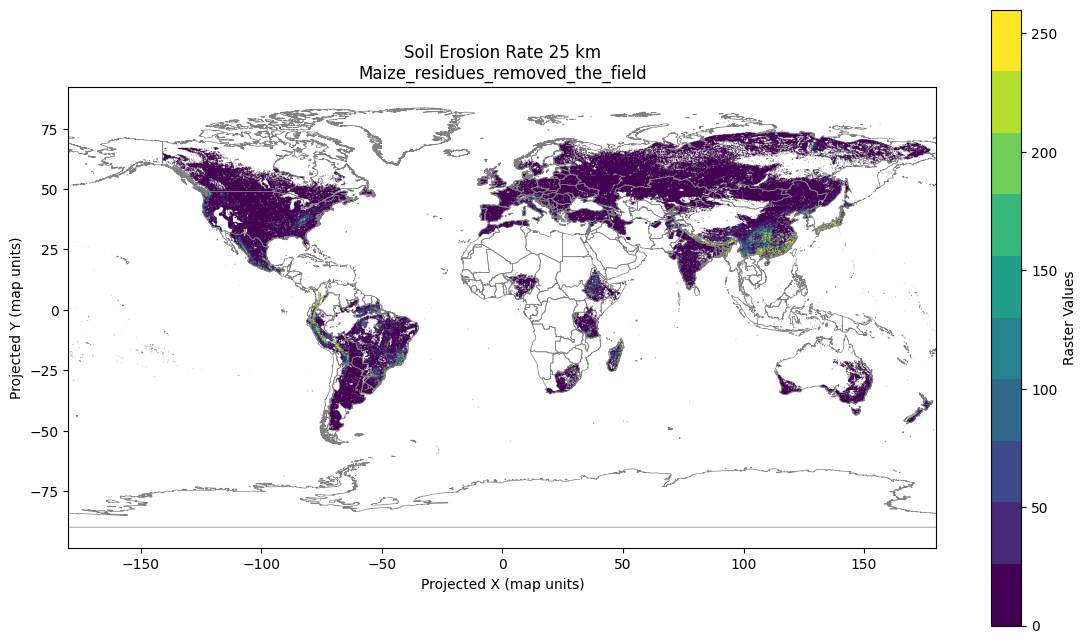

In [23]:
mp.plot_raster_on_world_extremes_cutoff(wheat_roff_se_leaf_fp, "Soil Erosion Rate 25 km\nMaize_residues_removed_the_field", perc_cutoff=1, quantiles=10)

C:\Users\loyola\OneDrive - World Wildlife Fund, Inc\Documents\203. Python projects\SBTN_Test\src\sbtn_leaf\map_plotting.py:218: RuntimeWarning: overflow encountered in cast
  data = src.read(raster_band).astype("float32", copy=False)
C:\Users\loyola\OneDrive - World Wildlife Fund, Inc\Documents\203. Python projects\SBTN_Test\src\sbtn_leaf\map_plotting.py:90: RuntimeWarning: overflow encountered in cast
  out[out == nodata_value] = np.nan


Raster has 163,785 unique values. Min: 0.00. Max: 1,791.64
Using quantiles
All positives route (quantiles)


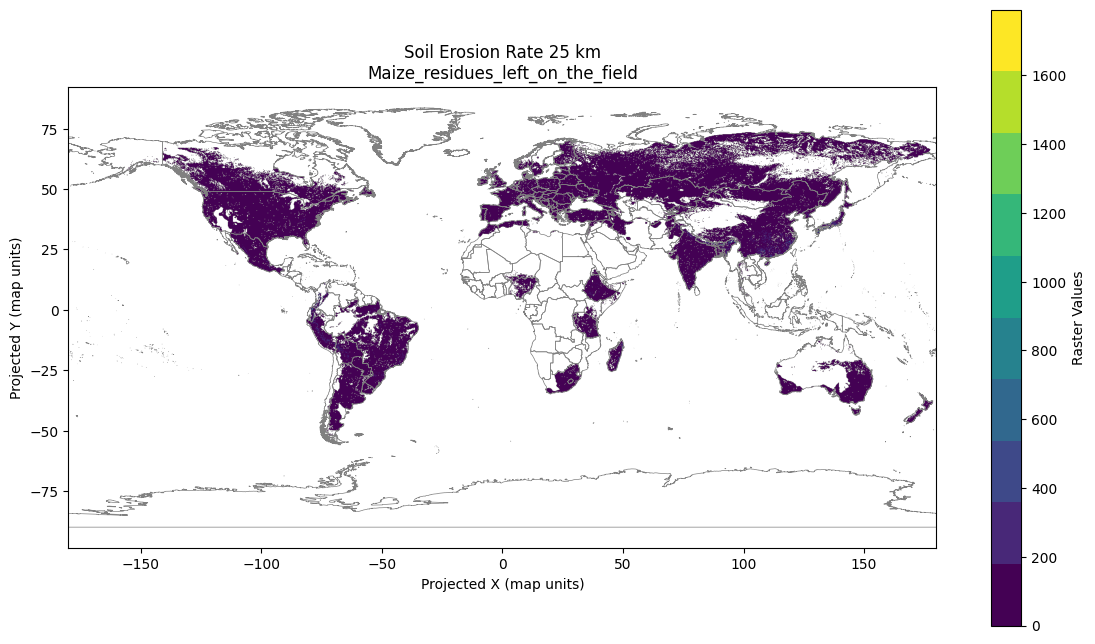

In [24]:
mp.plot_raster_on_world_extremes_cutoff(wheat_ron_se_leaf_fp, "Soil Erosion Rate 25 km\nMaize_residues_left_on_the_field", perc_cutoff= 0, quantiles=10)

As it can be seen, there seems to be some outliers, with same erosion rates going over 1,000 ton soil per year. Plotting with a 95% range of values:

C:\Users\loyola\OneDrive - World Wildlife Fund, Inc\Documents\203. Python projects\SBTN_Test\src\sbtn_leaf\map_plotting.py:218: RuntimeWarning: overflow encountered in cast
  data = src.read(raster_band).astype("float32", copy=False)
C:\Users\loyola\OneDrive - World Wildlife Fund, Inc\Documents\203. Python projects\SBTN_Test\src\sbtn_leaf\map_plotting.py:90: RuntimeWarning: overflow encountered in cast
  out[out == nodata_value] = np.nan


Raster has 145,046 unique values. Min: 0.24. Max: 86.62
Using quantiles
All positives route (quantiles)


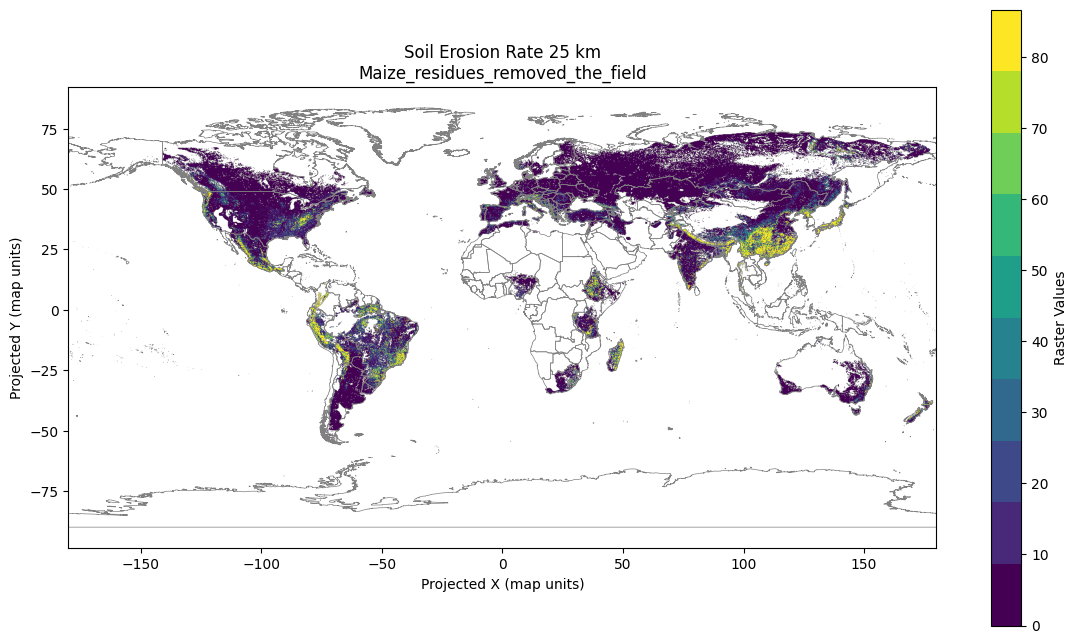

In [25]:
mp.plot_raster_on_world_extremes_cutoff(wheat_roff_se_leaf_fp, "Soil Erosion Rate 25 km\nMaize_residues_removed_the_field", perc_cutoff=5, quantiles=10)

C:\Users\loyola\OneDrive - World Wildlife Fund, Inc\Documents\203. Python projects\SBTN_Test\src\sbtn_leaf\map_plotting.py:218: RuntimeWarning: overflow encountered in cast
  data = src.read(raster_band).astype("float32", copy=False)
C:\Users\loyola\OneDrive - World Wildlife Fund, Inc\Documents\203. Python projects\SBTN_Test\src\sbtn_leaf\map_plotting.py:90: RuntimeWarning: overflow encountered in cast
  out[out == nodata_value] = np.nan


Raster has 147,753 unique values. Min: 0.21. Max: 76.11
Using quantiles
All positives route (quantiles)


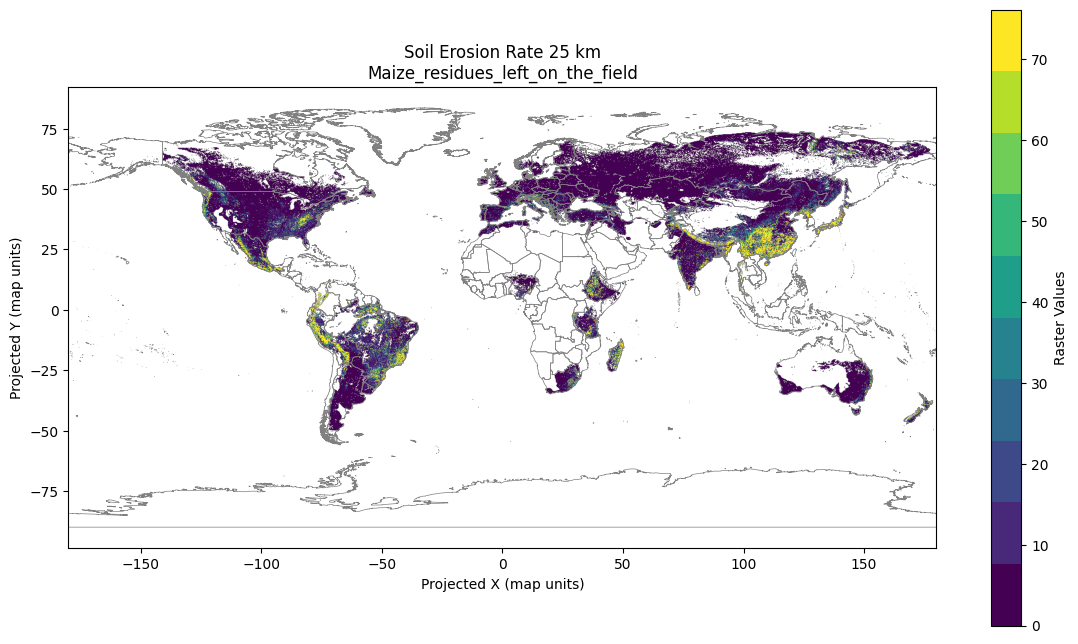

In [26]:
mp.plot_raster_on_world_extremes_cutoff(wheat_ron_se_leaf_fp, "Soil Erosion Rate 25 km\nMaize_residues_left_on_the_field", perc_cutoff=5, quantiles=10)

It shows a much more sensible map. It also shows that the maximum rates for leaving residues on the field erosion rates are lower, as expected.

### Clipping to X%


In [ ]:
mc.

## Step 4 - Country, Sub-country, and Ecoregion averages
After calculating a LEAF soil erosion raster for each land use, it's time to calculate averages per country, sub-country, and ecoregions. These are calculated as area-weighted ones. 

### Step 4.1 - Outliers filtering
Before proceeding to calculate averages per polygon, calculated erosion rates should be analyzed to defined the best way to deal with potential outliers.

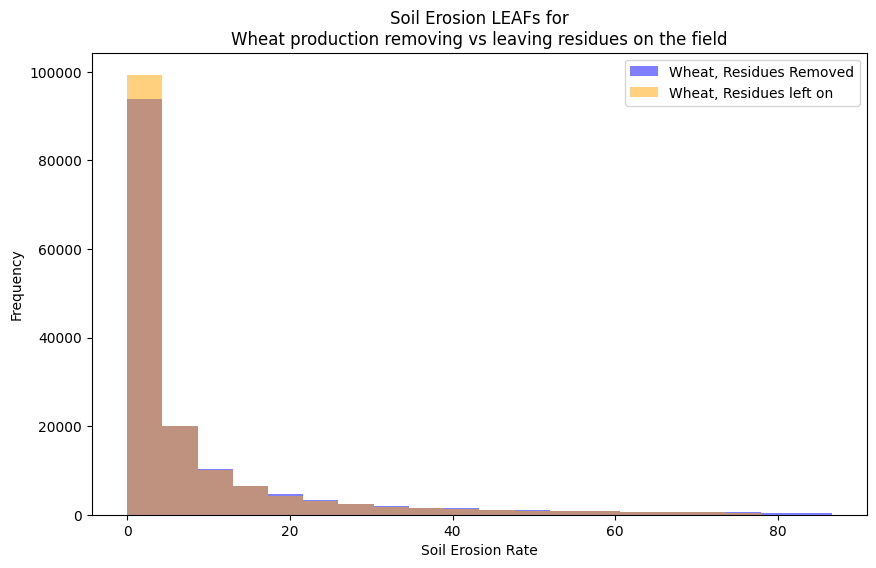

In [33]:
mp.plot_overlapping_histograms(
    raster1_path=wheat_roff_se_leaf_fp,
    raster2_path=wheat_ron_se_leaf_fp,
    title="Soil Erosion LEAFs for\nWheat production removing vs leaving residues on the field",
    x_label="Soil Erosion Rate",
    label1="Wheat, Residues Removed",
    label2="Wheat, Residues left on",
    bins = 20,
    quantiles_tails='right',
    filter_quantiles=0.05
)

In [34]:
with rasterio.open(wheat_roff_se_leaf_fp) as src:
    data = src.read(1, masked=True)

data_flat = data.compressed()

Now transforming with $data_t = \log(1+data)$. As this preserves 0 values (log(1) = 0)

In [35]:
data_t = np.log1p(data_flat)

This looks better distributed

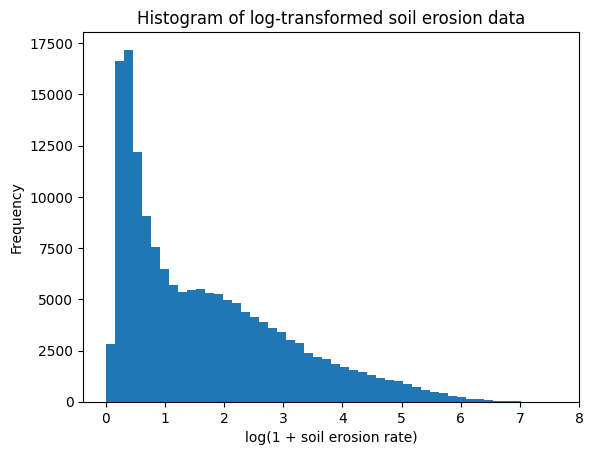

In [36]:
plt.hist(data_t[~np.isnan(data_t)], bins=50)
plt.title("Histogram of log-transformed soil erosion data")
plt.xlabel("log(1 + soil erosion rate)")
plt.ylabel("Frequency")
plt.show()

Now calculating mean and dev of the logtransformed data

In [37]:
mean_dt = np.nanmean(data_t)
std_dt = np.nanstd(data_t)

print(f'Log transformed stats: mean: {mean_dt}, std: {std_dt}')

Log transformed stats: mean: 1.678990030025431, std: 1.3798155592670553


Now filtering the data on mean + 3*std

In [38]:
data_t_f = data_t[data_t <= (mean_dt+3*std_dt)]

Checking how it looks...

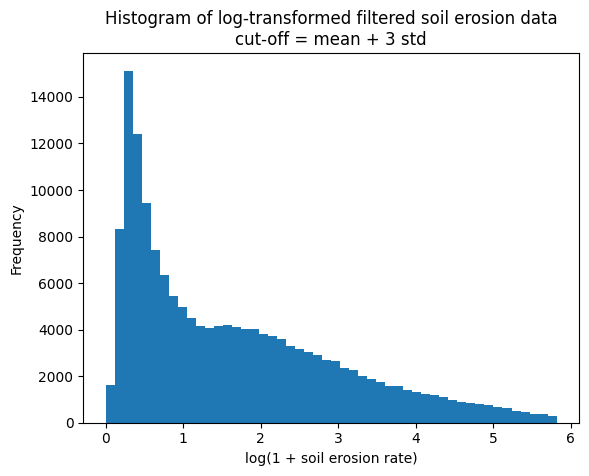

In [39]:
plt.hist(data_t_f[~np.isnan(data_t_f)], bins=50)
plt.title("Histogram of log-transformed filtered soil erosion data\ncut-off = mean + 3 std")
plt.xlabel("log(1 + soil erosion rate)")
plt.ylabel("Frequency")
plt.show()

Which basically cuts the tail close to 6 and over

Un-transforming the data

In [40]:
data_f = np.exp(data_t_f) - 1

Finally comparing mean and std of both:

In [45]:
# Original data
mean_d = np.nanmean(data_flat)
std_d = np.nanstd(data_flat)

# Filtered data
mean_d_f = np.nanmean(data_f)
std_d_f = np.nanstd(data_f)

# Printing
print(f'Unfiltered values - Mean {mean_d} | Std {std_d}')
print(f'Filtered values - Mean {mean_d_f} | Std {std_d_f}')

Unfiltered values - Mean 18.016991082418958 | Std 53.33236638705852
Filtered values - Mean 15.269619829926823 | Std 36.64694849008393


Now comparing how both distribution look.

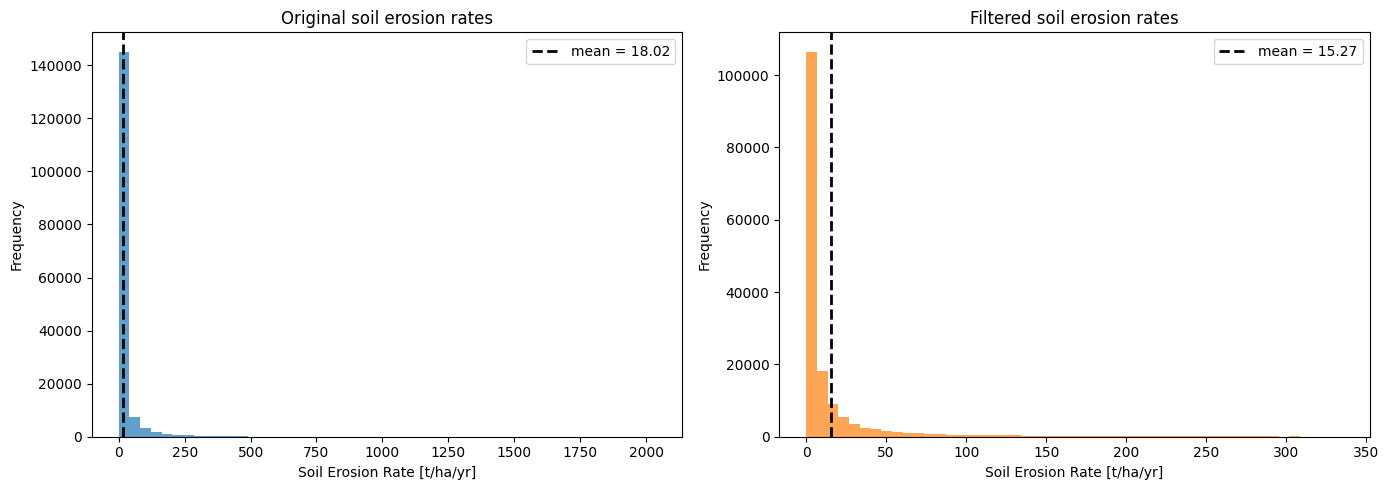

In [46]:
# Plot side-by-side histograms of original and filtered data with vertical mean lines

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: original (data_flat)
orig = data_flat[~np.isnan(data_flat)]
axes[0].hist(orig, bins=50, color='C0', alpha=0.7)
axes[0].axvline(mean_d, color='k', linestyle='--', linewidth=2, label=f"mean = {mean_d:.2f}")
axes[0].set_title("Original soil erosion rates")
axes[0].set_xlabel("Soil Erosion Rate [t/ha/yr]")
axes[0].set_ylabel("Frequency")
axes[0].legend()

# Right: filtered (data_f)
filt = data_f[~np.isnan(data_f)]
axes[1].hist(filt, bins=50, color='C1', alpha=0.7)
axes[1].axvline(mean_d_f, color='k', linestyle='--', linewidth=2, label=f"mean = {mean_d_f:.2f}")
axes[1].set_title("Filtered soil erosion rates")
axes[1].set_xlabel("Soil Erosion Rate [t/ha/yr]")
axes[1].set_ylabel("Frequency")
axes[1].legend()

plt.tight_layout()
plt.show()

Which still shows a heavily skewed disitribution, but eliminating the extremely high values over 350 ton soil/ha/year

### Step 4.2 - LEAFs averages

Now that this has been identified, average per geometry are calculated eliminating this outliers

In [2]:
# Defining needed inputs
country_shp = gpd.read_file("../data/CountryLayers/Country_Level0/g2015_2014_0.shp")

In [ ]:
master_key = "ADM0_NAME"

Checking to see if there are duplicated rows...

In [9]:
# Prepare master_gdf if it has several repeated rows
repated_master_key_rows = country_shp[master_key][country_shp[master_key].duplicated()].unique()
repated_master_key_amount = repated_master_key_rows.shape[0]
print(f"There are {repated_master_key_amount} repeated rows, which are:\n {repated_master_key_rows}")

if repated_master_key_amount > 0:
    print('Eliminating duplicat rows')
    corrected_shp = mc.prep_master_unique(country_shp, "ADM0_NAME", strategy="dissolve")

There are 1 repeated rows, which are:
 ['West Bank']
Eliminating duplicat rows


Saving it as it takes a long time...

In [ ]:
# corrected_shp.to_file('../data/CountryLayers/Country_Level0/g2015_2014_0_dissolved.shp')
corrected_shp = gpd.read_file('../data/CountryLayers/Country_Level0/g2015_2014_0_dissolved.shp')

Now running the function. Considering soil erosion rates distribution, we'll use the same outliers filtering method as previously shown.

In [ ]:
gpkg_path, df_results = mc.build_cfs_gpkg_from_rasters(
    input_folder = "../LEAFs/soil_erosion/raster/",
    output_folder = "../LEAFs/soil_erosion/country/",
    layer_name="se_leaf_country",
    master_gdf=corrected_shp,   # e.g., countries, subcountries, or ecoregions
    master_key="ADM0_NAME",            # or 'ISO_A3', 'ADM1_NAME', 'ECO_NAME'
    result_key="country",              # must match the column emitted by your calc gdf
    input_raster_key_startswith="se_rate_25km_",
    cf_name="soil_erosion",
    cf_unit="t soil/ha/yr",
    area_type="country",
    calc_kwargs=dict(outlier_method="log1p_win"),  # Replaces all values above a threshold by the threhsold
    reset_gpkg=True,
    promote_to_multi=True,
    add_source_file_name=True,
    # run_test=True                             # Use run test to run the first 3 files
)

print(f"Wrote {df_results.shape[0]} rows into {gpkg_path}")

2025-10-15 14:10:54,652 - INFO - Building 'se_leaf_country' from rasters in ../LEAFs/soil_erosion/raster/ into ../LEAFs/soil_erosion/country/ (../LEAFs/soil_erosion/country/soil_erosion_country.gpkg)

2025-10-15 14:11:07,436 - INFO - Starting: Calculating country weighted CF for Broadleaf_Deciduous_Boreal_dry using outlier filtering method log1p_win
2025-10-15 14:12:12,484 - INFO - Calculations complete for ../LEAFs/soil_erosion/raster/se_rate_25km_Broadleaf_Deciduous_Boreal_dry.tif! Found matches for 8 regions.

2025-10-15 14:12:12,604 - INFO - Starting: Calculating country weighted CF for Broadleaf_Deciduous_Boreal_moist using outlier filtering method log1p_win
2025-10-15 14:13:12,014 - INFO - Calculations complete for ../LEAFs/soil_erosion/raster/se_rate_25km_Broadleaf_Deciduous_Boreal_moist.tif! Found matches for 8 regions.

2025-10-15 14:13:12,161 - INFO - Starting: Calculating country weighted CF for Broadleaf_Deciduous_Cold_temperate_dry using outlier filtering method log1p_win


Wrote 66240 rows into ../LEAFs/soil_erosion/country/soil_erosion_country.gpkg


Checking outputs

In [12]:
gdf_test_values = gpd.read_file(gpkg_path, layer="se_leaf_country")
gdf_test_values.sort_values(by=["cf"]).head()

,ADM0_NAME,flow_name,cf,cf_median,cf_std,_source_file
12674,Turkmenistan,Needleleaf_Evergreen_Cold_temperate_moist,0.0000,0.0000,0.0000,se_rate_25km_Needleleaf_Evergreen_Cold_tempera...
12685,Uzbekistan,Needleleaf_Evergreen_Cold_temperate_moist,0.0001,0.0000,0.0001,se_rate_25km_Needleleaf_Evergreen_Cold_tempera...
12598,Netherlands,Needleleaf_Evergreen_Cold_temperate_moist,0.0002,0.0002,0.0001,se_rate_25km_Needleleaf_Evergreen_Cold_tempera...
12787,Gaza Strip,Needleleaf_Evergreen_Subtropical,0.0002,0.0002,0.0000,se_rate_25km_Needleleaf_Evergreen_Subtropical.tif
12553,Kazakhstan,Needleleaf_Evergreen_Cold_temperate_moist,0.0002,0.0002,0.0003,se_rate_25km_Needleleaf_Evergreen_Cold_tempera...


And it can be seen that the output has all values. Opening the dataset it can be seen it include NaNs.

To plot it, the geoemtries layer need to be imported as:

In [13]:
gdf_test_geometries = gpd.read_file(gpkg_path, layer="geometry_layer")

And then merged.

In [14]:
gdf_test = gdf_test_geometries.merge(gdf_test_values.drop(columns="_source_file"), how="left", on="ADM0_NAME")

Plotting, using Broadleaf_Deciduous_Cold_temperate_dry as example

In [15]:
wheat_rainfed_roff = gdf_test[gdf_test["flow_name"]=="Rainfed_Wheat_residues_removed_from_the_field"]

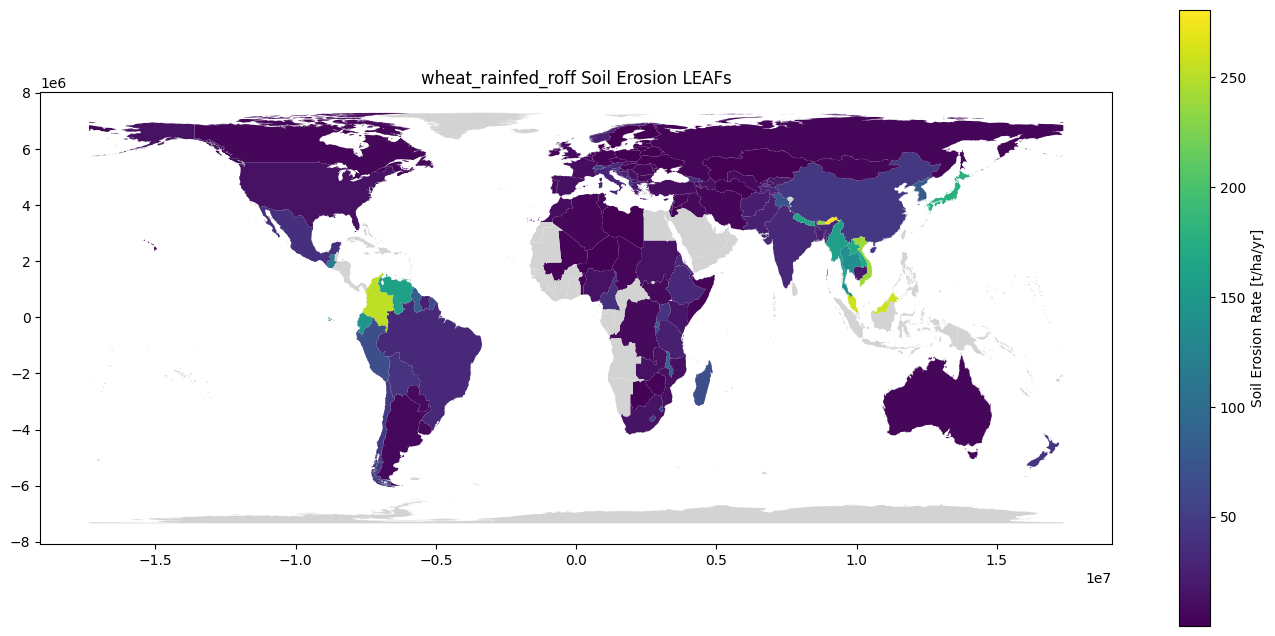

In [16]:
fig, ax = plt.subplots(figsize=(14, 8)) 
wheat_rainfed_roff.plot(column="cf", ax=ax, cmap="viridis", 
           legend=True, 
           legend_kwds={"label": "Soil Erosion Rate [t/ha/yr]", "shrink": 0.8}, 
           missing_kwds={"color": "lightgrey", "label": "No value"}) 

ax.set_title("wheat_rainfed_roff Soil Erosion LEAFs")
plt.tight_layout() 
plt.show()

Checking df

In [21]:
df_results.sort_values(by="value", ascending=False).head()

,ADM0_NAME,value,metric,flow_name
65746,Comoros,1881.906965,cf_median,Urban
65470,Comoros,1881.906965,cf_mean,Urban
65592,New Caledonia,1509.368941,cf_mean,Urban
65654,Taiwan,1393.241503,cf_mean,Urban
65426,Arunachal Pradesh,1324.491573,cf_mean,Urban


It can be seen that holds the same information

##### Sub-Country
Repeating the process with subcountries

First, correcting the shapefile to eliminate duplicated names, if any

In [4]:
# Defining needed inputs
subcountry_shp = gpd.read_file("../data/CountryLayers/SubCountry_Level1/g2015_2014_1.shp")
master_key = "ADM1_CODE"

In [26]:
# Prepare master_gdf if it has several repeated rows
repated_master_key_rows = subcountry_shp[master_key][subcountry_shp[master_key].duplicated()].unique()
repated_master_key_amount = repated_master_key_rows.shape[0]
print(f"There are {repated_master_key_amount} repeated rows, which are:\n {repated_master_key_rows}")

There are 0 repeated rows, which are:
 []


So there are now repeated sub-country geom IDs, so we'll go ahead and do the calculations based on that

Running the code

In [ ]:
gpkg_path_sc, df_results_sc = mc.build_cfs_gpkg_from_rasters(
    input_folder = "../LEAFs/soil_erosion/raster/",
    output_folder = "../LEAFs/soil_erosion/",
    layer_name="se_leaf_subcountry",
    master_gdf=subcountry_shp,              # e.g., countries, subcountries, or ecoregions
    master_key="ADM1_CODE",                 # must be 'ADM0_NAME' for countries, 'ADM1_CODE' for subcountries, and 'ECO_NAME' for ecoregions
    result_key="ADM1_CODE",                 # must match the column emitted by your calc gdf
    input_raster_key_startswith="se_rate_25km_",
    cf_name="soil_erosion",
    cf_unit="t soil/ha/yr",
    area_type="subcountry",
    calc_kwargs=dict(outlier_method="log1p_win"),  # Replaces all values above a threshold by the threhsold
    reset_gpkg=True,
    promote_to_multi=True,
    add_source_file_name=True,
    # run_test=True                             # Use run test to run the first 3 files
)

print(f"Wrote {df_results_sc.shape[0]} rows into {gpkg_path_sc}")

2025-10-16 11:43:05,634 - INFO - Building 'se_leaf_subcountry' from rasters in ../LEAFs/soil_erosion/raster/ into ../LEAFs/soil_erosion/ (../LEAFs/soil_erosion/soil_erosion_subcountry.gpkg)

2025-10-16 11:43:21,382 - INFO - Starting: Calculating subcountry weighted CF for Broadleaf_Deciduous_Boreal_dry using outlier filtering method log1p_win
2025-10-16 11:45:44,828 - INFO - Calculations complete for ../LEAFs/soil_erosion/raster/se_rate_25km_Broadleaf_Deciduous_Boreal_dry.tif! Found matches for 86 regions.

2025-10-16 11:45:44,893 - INFO - Starting: Calculating subcountry weighted CF for Broadleaf_Deciduous_Boreal_moist using outlier filtering method log1p_win
2025-10-16 11:48:00,021 - INFO - Calculations complete for ../LEAFs/soil_erosion/raster/se_rate_25km_Broadleaf_Deciduous_Boreal_moist.tif! Found matches for 85 regions.

2025-10-16 11:48:00,246 - INFO - Starting: Calculating subcountry weighted CF for Broadleaf_Deciduous_Cold_temperate_dry using outlier filtering method log1p_win

Wrote 821280 rows into ../LEAFs/soil_erosion/soil_erosion_subcountry.gpkg


Checking datasets were generated ok

In [77]:
gdf_sc_geometries = gpd.read_file(gpkg_path_sc, layer="geometry_layer")

In [56]:
gdf_sc_values = gpd.read_file(gpkg_path_sc, layer="se_leaf_subcountry")
gdf_sc_values.sort_values(by=["cf"], ascending=False).head(10)

,ADM1_CODE,flow_name,cf,cf_median,cf_std,_source_file
272469,41310,Urban,3202.050293,2726.118652,5.321078e+02,se_rate_25km_Urban.tif
272011,1689,Urban,3059.956299,2937.229736,1.308386e+03,se_rate_25km_Urban.tif
271999,1677,Urban,2935.945557,2800.448975,1.740828e+03,se_rate_25km_Urban.tif
272489,70037,Urban,2820.671387,2820.671387,4.547474e-13,se_rate_25km_Urban.tif
272105,3375,Urban,2666.205078,3131.139893,9.570369e+02,se_rate_25km_Urban.tif
271992,1670,Urban,2641.790039,2104.138184,2.008518e+03,se_rate_25km_Urban.tif
271991,1669,Urban,2520.910645,2584.898682,9.276956e+02,se_rate_25km_Urban.tif
272329,2957,Urban,2494.704102,2494.704102,0.000000e+00,se_rate_25km_Urban.tif
271781,959,Urban,2467.089600,1648.830566,1.310724e+03,se_rate_25km_Urban.tif
271996,1674,Urban,2389.641602,2159.461670,1.342035e+03,se_rate_25km_Urban.tif


In [57]:
df_results_sc.head()

,ADM1_CODE,value,metric,flow_name,ADM1_NAME,ADM0_NAME
0,40542,NaN,cf_mean,Broadleaf_Deciduous_Boreal_dry,Bubanza,Burundi
1,40543,NaN,cf_mean,Broadleaf_Deciduous_Boreal_dry,Bujumbura Mairie,Burundi
2,40544,NaN,cf_mean,Broadleaf_Deciduous_Boreal_dry,Bujumbura Rural,Burundi
3,40545,NaN,cf_mean,Broadleaf_Deciduous_Boreal_dry,Bururi,Burundi
4,40546,NaN,cf_mean,Broadleaf_Deciduous_Boreal_dry,Cankuzo,Burundi


Now checking some of the results for Broadleaf_Deciduous_Cold_temperate_dry.

In [58]:
gdf_sc = gdf_sc_geometries.merge(gdf_sc_values, how="left", on="ADM1_CODE").drop(columns="_source_file")

In [59]:
gdf_sc_testflow = gdf_sc[gdf_sc["flow_name"] == "Rainfed_Wheat_residues_removed_from_the_field"]

Now plotting

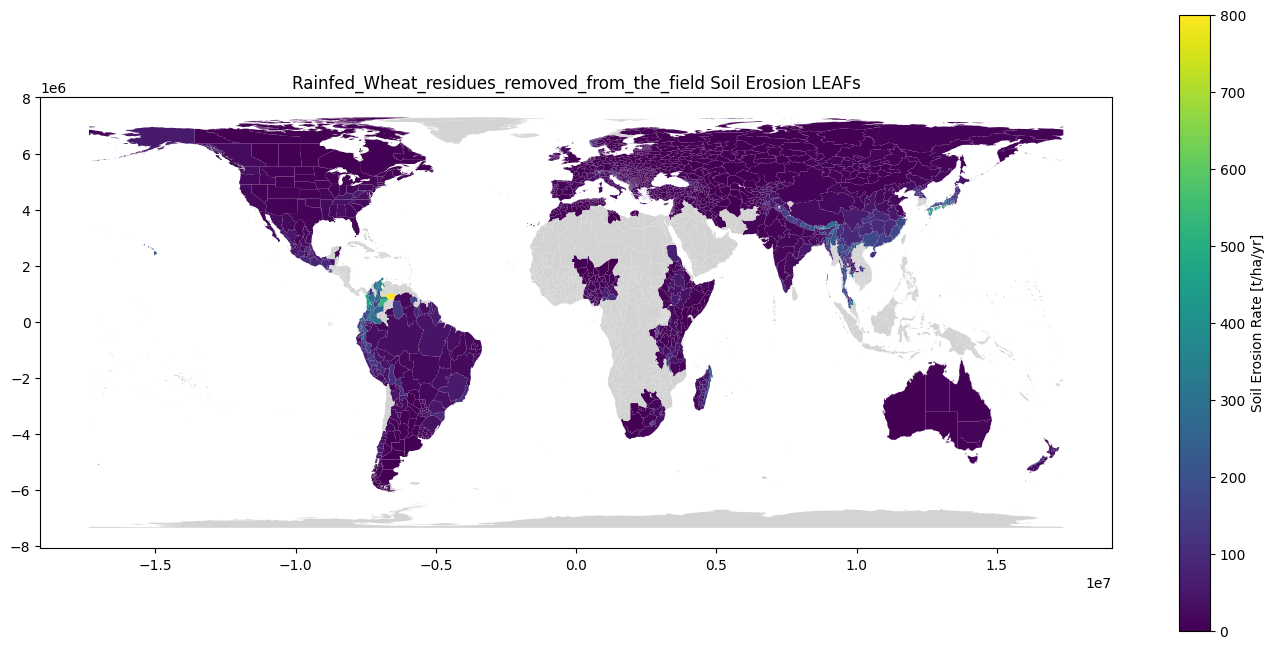

In [60]:
fig, ax = plt.subplots(figsize=(14, 8))
gdf_sc_testflow.plot(column="cf", ax=ax, cmap="viridis", legend=True, 
           legend_kwds={"label": "Soil Erosion Rate [t/ha/yr]", "shrink": 0.8}, 
           missing_kwds={"color": "lightgrey", "label": "No value"}
           ) 

ax.set_title("Rainfed_Wheat_residues_removed_from_the_field Soil Erosion LEAFs")
plt.tight_layout() 
plt.show()

Just Colombia, as it has high values compared to the rest

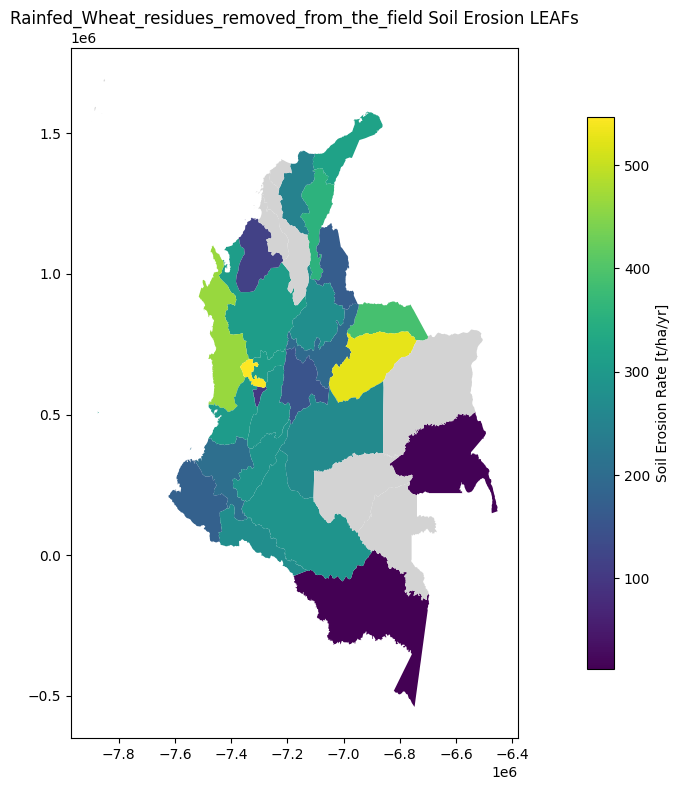

In [61]:
fig, ax = plt.subplots(figsize=(14, 8))
gdf_sc_testflow[gdf_sc_testflow["ADM0_NAME"] == "Colombia"].plot(column="cf", ax=ax, cmap="viridis", legend=True, 
           legend_kwds={"label": "Soil Erosion Rate [t/ha/yr]", "shrink": 0.8}, 
           missing_kwds={"color": "lightgrey", "label": "No value"}
           ) 

ax.set_title("Rainfed_Wheat_residues_removed_from_the_field Soil Erosion LEAFs")
plt.tight_layout() 
plt.show()

In [17]:
test_raster = "../LEAFs/soil_erosion/raster/se_rate_25km_Rainfed_Wheat_residues_removed_from_the_field.tif"

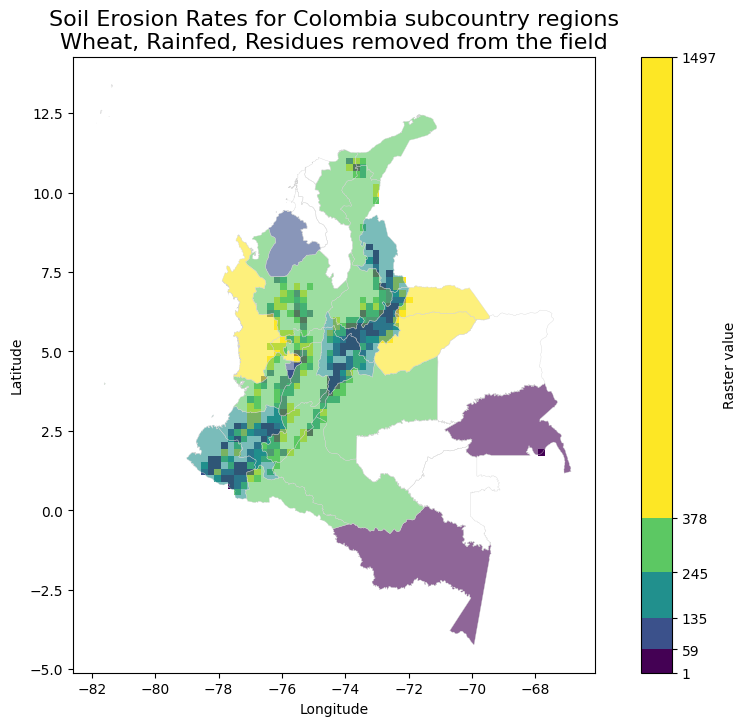

(<Figure size 1200x800 with 2 Axes>,
 <Axes: title={'center': 'Soil Erosion Rates for Colombia subcountry regions\nWheat, Rainfed, Residues removed from the field'}, xlabel='Longitude', ylabel='Latitude'>)

In [ ]:
mp.plot_raster_over_gdf_showpolygonvalues(test_raster, gdf_sc_testflow[gdf_sc_testflow["ADM0_NAME"] == "Colombia"], title="Soil Erosion Rates for Colombia subcountry regions\nWheat, Rainfed, Residues removed from the field",polygon_linewidth=0.25, polygon_value_col="cf", match_color_scale=True, n_quantiles=5, perc_cutoff=1)

So it can be seen than the average worked fine. It can also be seen that the overlap in some regions is not large, and wheat production is concentrated in just a couple of strips, with averages going between 12 to 500 ton soil/ha/yr, comparing it witht he average of 252 that the country gives.

It can also be seen that very high-values in some regions are overlapped minimally, which highlight the need to favour LEAFs defined at a finer resolution than sub-countries for companies.

### 4.3 - Ecoregions

Finally, ecoregion averages are calculated.

##### Checking shapefile

In [3]:
er_shp = gpd.read_file("../data/Ecoregions2017/Ecoregions2017.shp")

Ecoregions are also processed by ecoregion ID instead of name, so checking if there're ducplicated of those

In [71]:
master_key = "OBJECTID"

In [72]:
# Prepare master_gdf if it has several repeated rows
repated_master_key_rows = er_shp[master_key][er_shp[master_key].duplicated()].unique()
repated_master_key_amount = repated_master_key_rows.shape[0]
print(f"There are {repated_master_key_amount} repeated rows, which are:\n {repated_master_key_rows}")


There are 0 repeated rows, which are:
 []


So no geometries sharing the same name.

##### Calculating averages

In [ ]:
gpkg_path_er, df_results_er = mc.build_cfs_gpkg_from_rasters(
    input_folder = "../LEAFs/soil_erosion/raster/",
    output_folder = "../LEAFs/soil_erosion/",
    layer_name="se_leaf_ecoregions",
    master_gdf=er_shp,              # e.g., countries, subcountries, or ecoregions
    master_key="OBJECTID",                 # must be 'ADM0_NAME' for countries, 'ADM1_CODE' for subcountries, and 'ECO_NAME' for ecoregions
    result_key="er_geom_id",                 # must match the column emitted by your calc gdf
    input_raster_key_startswith="se_rate_25km_",
    cf_name="soil_erosion",
    cf_unit="t soil/ha/yr",
    area_type="ecoregion",
    calc_kwargs=dict(outlier_method="log1p_win"),  # Replaces all values above a threshold by the threhsold
    reset_gpkg=True,
    promote_to_multi=True,
    add_source_file_name=True,
    # run_test=True                             # Use run test to run the first 3 files
)

print(f"Wrote {df_results_er.shape[0]} rows into {gpkg_path_er}")

2025-10-17 13:39:22,733 - INFO - Building 'se_leaf_ecoregions' from rasters in ../LEAFs/soil_erosion/raster/ into ../LEAFs/soil_erosion/ (../LEAFs/soil_erosion/soil_erosion_ecoregion.gpkg)



Processing rasters (se_leaf_ecoregions):   0%|          | 0/80 [00:00<?, ?raster/s]

2025-10-17 13:39:28,543 - INFO - Calculating soil_erosion for Broadleaf_Deciduous_Boreal_dry...
Calculating soil_erosion for Broadleaf_Deciduous_Boreal_dry...
2025-10-17 13:41:23,367 - INFO - Calculating soil_erosion for Broadleaf_Deciduous_Boreal_moist...
Calculating soil_erosion for Broadleaf_Deciduous_Boreal_moist...
2025-10-17 13:43:57,170 - INFO - Calculating soil_erosion for Broadleaf_Deciduous_Cold_temperate_dry...
Calculating soil_erosion for Broadleaf_Deciduous_Cold_temperate_dry...
2025-10-17 13:47:10,828 - INFO - Calculating soil_erosion for Broadleaf_Deciduous_Cold_temperate_moist...
Calculating soil_erosion for Broadleaf_Deciduous_Cold_temperate_moist...
2025-10-17 13:49:58,564 - INFO - Calculating soil_erosion for Broadleaf_Deciduous_Subtropical...
Calculating soil_erosion for Broadleaf_Deciduous_Subtropical...
2025-10-17 13:52:22,801 - INFO - Calculating soil_erosion for Broadleaf_Deciduous_Tropical...
Calculating soil_erosion for Broadleaf_Deciduous_Tropical...
2025-10-

Wrote 203280 rows into ../LEAFs/soil_erosion/soil_erosion_ecoregion.gpkg


Checking datasets were generated ok

In [4]:
gpkg_path_er = "../LEAFs/soil_erosion/soil_erosion_ecoregion.gpkg"

In [5]:
gdf_er_geometries = gpd.read_file(gpkg_path_er, layer="geometry_layer")

In [6]:
gdf_er_values = gpd.read_file(gpkg_path_er, layer="se_leaf_ecoregions")
gdf_er_values.sort_values(by=["cf"], ascending=False).head(10)

,OBJECTID,flow_name,cf,cf_median,cf_std,_source_file
67237,328.0,Urban,2052.479492,1900.610229,1.098878e+03,se_rate_25km_Urban.tif
67153,244.0,Urban,1899.165649,1697.285156,1.086563e+03,se_rate_25km_Urban.tif
67087,176.0,Urban,1881.906982,1881.906982,0.000000e+00,se_rate_25km_Urban.tif
67613,706.0,Urban,1803.205200,1645.490356,1.004601e+03,se_rate_25km_Urban.tif
67163,254.0,Urban,1800.513428,1800.513428,2.273737e-13,se_rate_25km_Urban.tif
67431,523.0,Urban,1792.837891,1891.826660,5.937972e+02,se_rate_25km_Urban.tif
67383,475.0,Urban,1749.843872,1346.700684,1.199728e+03,se_rate_25km_Urban.tif
67147,238.0,Urban,1635.183105,1450.625244,9.700507e+02,se_rate_25km_Urban.tif
67306,398.0,Urban,1634.204102,1735.793701,5.821135e+02,se_rate_25km_Urban.tif
67631,724.0,Urban,1615.839844,1450.092651,7.241859e+02,se_rate_25km_Urban.tif


In [12]:
df_results_er = pl.read_csv("../LEAFs/soil_erosion/soil_erosion_ecoregion.csv")
df_results_er.head()

OBJECTID,er_geom_id,value,metric,flow_name,ECO_NAME,BIOME_NUM,BIOME_NAME,REALM
f64,f64,f64,str,str,str,f64,str,str
1.0,null,null,"""cf_mean""","""Broadleaf_Deciduous_Boreal_dry""","""Adelie Land tundra""",11.0,"""Tundra""","""Antarctica"""
2.0,null,null,"""cf_mean""","""Broadleaf_Deciduous_Boreal_dry""","""Admiralty Islands lowland rain…",1.0,"""Tropical & Subtropical Moist B…","""Australasia"""
3.0,null,null,"""cf_mean""","""Broadleaf_Deciduous_Boreal_dry""","""Aegean and Western Turkey scle…",12.0,"""Mediterranean Forests, Woodlan…","""Palearctic"""
4.0,null,null,"""cf_mean""","""Broadleaf_Deciduous_Boreal_dry""","""Afghan Mountains semi-desert""",13.0,"""Deserts & Xeric Shrublands""","""Palearctic"""
5.0,5.0,0.031443,"""cf_mean""","""Broadleaf_Deciduous_Boreal_dry""","""Ahklun and Kilbuck Upland Tund…",11.0,"""Tundra""","""Nearctic"""


Results look ok. Merging the geometries and plotting

In [7]:
gdf_er = gdf_er_geometries.merge(gdf_er_values, how="left", on="OBJECTID").drop(columns="_source_file")

Filtering for a flow...

In [12]:
gdf_er_testflow = gdf_er[gdf_er["flow_name"] == "Rainfed_Wheat_residues_removed_from_the_field"]

Now plotting

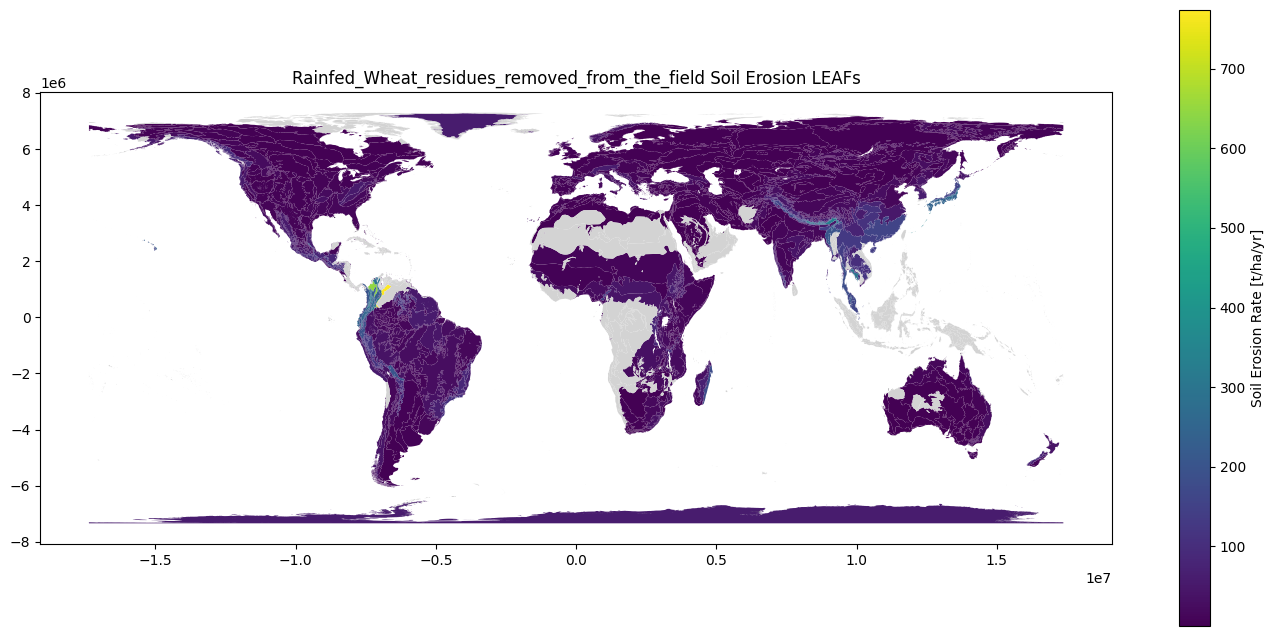

In [27]:
fig, ax = plt.subplots(figsize=(14, 8))
gdf_er_testflow.plot(column="cf", ax=ax, cmap="viridis", legend=True, 
           legend_kwds={"label": "Soil Erosion Rate [t/ha/yr]", "shrink": 0.8}, 
           missing_kwds={"color": "lightgrey", "label": "No value"}
           ) 

ax.set_title("Rainfed_Wheat_residues_removed_from_the_field Soil Erosion LEAFs")
plt.tight_layout() 
plt.show()

Now zooming into the ecoregions around Colombia for a better comparison. These are:

In [12]:
country_shp = country_shp.to_crs(gdf_er.crs)

In [8]:
co_ers = er_shp.overlay(country_shp[country_shp["ADM0_NAME"]=="Colombia"])

In [14]:
co_ers = co_ers.merge(gdf_er_testflow[["OBJECTID", "cf", "cf_median", "cf_std"]], how="left", on= "OBJECTID")

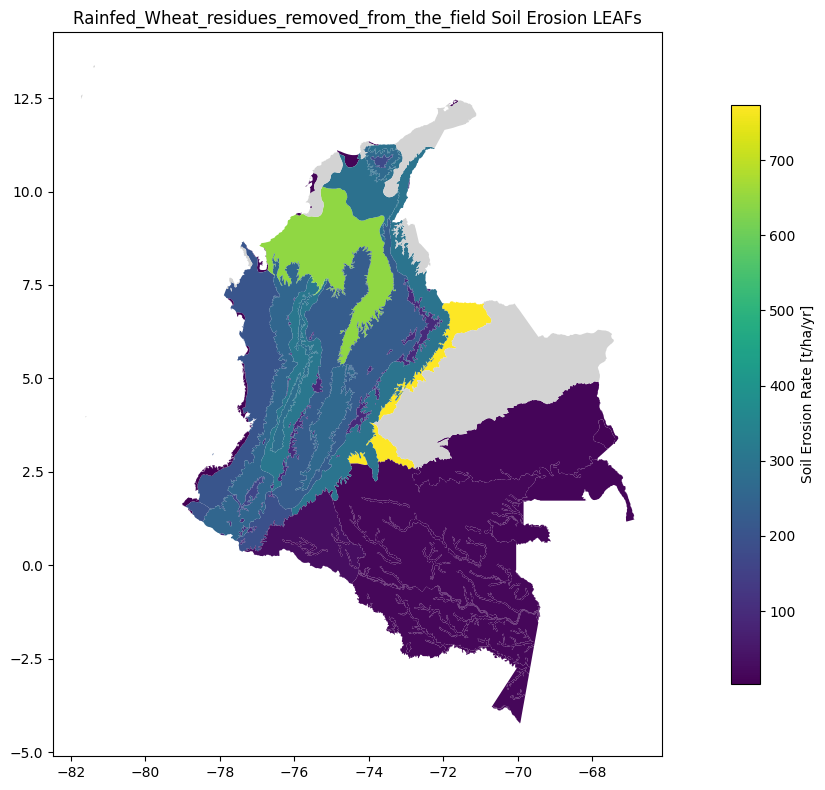

In [16]:
fig, ax = plt.subplots(figsize=(14, 8))
co_ers.plot(column="cf", ax=ax, cmap="viridis", legend=True, 
           legend_kwds={"label": "Soil Erosion Rate [t/ha/yr]", "shrink": 0.8}, 
           missing_kwds={"color": "lightgrey", "label": "No value"}
           ) 

ax.set_title("Rainfed_Wheat_residues_removed_from_the_field Soil Erosion LEAFs")
plt.tight_layout() 
plt.show()

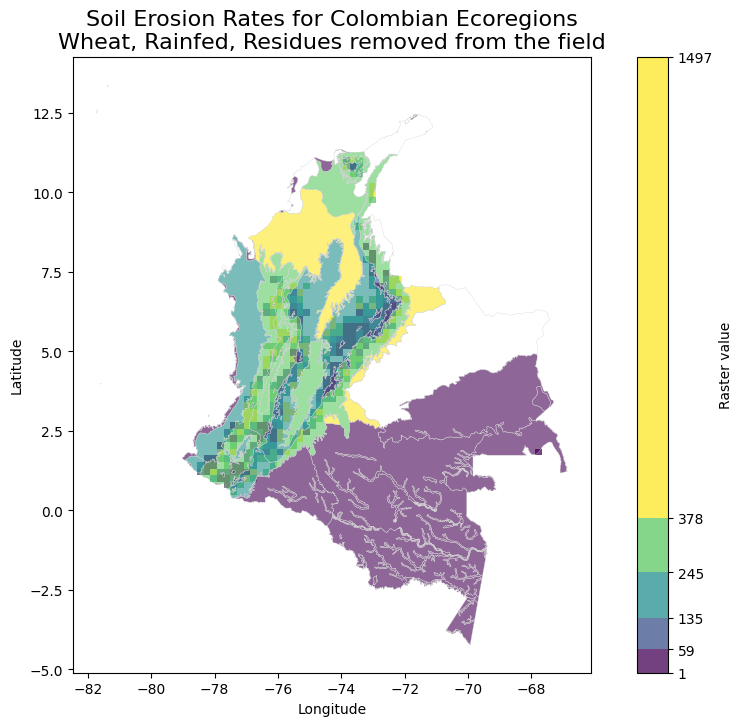

(<Figure size 1200x800 with 2 Axes>,
 <Axes: title={'center': 'Soil Erosion Rates for Colombian Ecoregions\nWheat, Rainfed, Residues removed from the field'}, xlabel='Longitude', ylabel='Latitude'>)

In [ ]:
mp.plot_raster_over_gdf_showpolygonvalues(test_raster, co_ers, title="Soil Erosion Rates for Colombian Ecoregions\nWheat, Rainfed, Residues removed from the field",polygon_linewidth=0.25, polygon_value_col="cf", match_color_scale=True, n_quantiles=5)

It can be seen that there's a better alignment between pixel coverage and some ecoregions, and has a similar range of values than sub-country averages.